In [178]:
from skimage.io import imread
import numpy as np
from matplotlib import pyplot as plt
import time
import os

In [179]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Useful function for plotting a 2D dictionary

In [180]:
def get_dictionary_img(D):
    M = D.shape[0]
    p = int(round(np.sqrt(M)))
    bound = 2
    img = np.ones((p*p+bound*(p-1), p*p+bound*(p-1)))
    for i in range(M):
        m = np.mod(i, p)
        n = int((i-m)/p)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Load the image and rescale it in $[0,1]$

In [181]:
Myimg = False

In [182]:
if Myimg == True:
  rootfolder = "./MyImages"
  img = imread(f'{rootfolder}/Azores_Canon.jpeg') / 255

  img_gray = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])

  new_size = 2560
  h, w = img_gray.shape

  start_y = (h - new_size) // 2
  start_x = (w - new_size) // 2

  # slicing
  img_cropped = img_gray[start_y:start_y + new_size, start_x:start_x + new_size]
  img = img_cropped
else:
  # img = imread(f'{rootfolder}/data/cameraman.png') / 255
  # img = imread(f'{rootfolder}/data/barbara.png') / 255
  img = imread(f'{rootfolder}/data/Lena512.png') / 255

In [183]:
imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Corrupt the image with white gaussian noise

In [184]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(size=imsz) * sigma_noise

Compute the psnr of the noisy input

In [185]:
psnr_noisy = 10 * np.log10(1 / np.mean(np.square(noisy_img - img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.13')

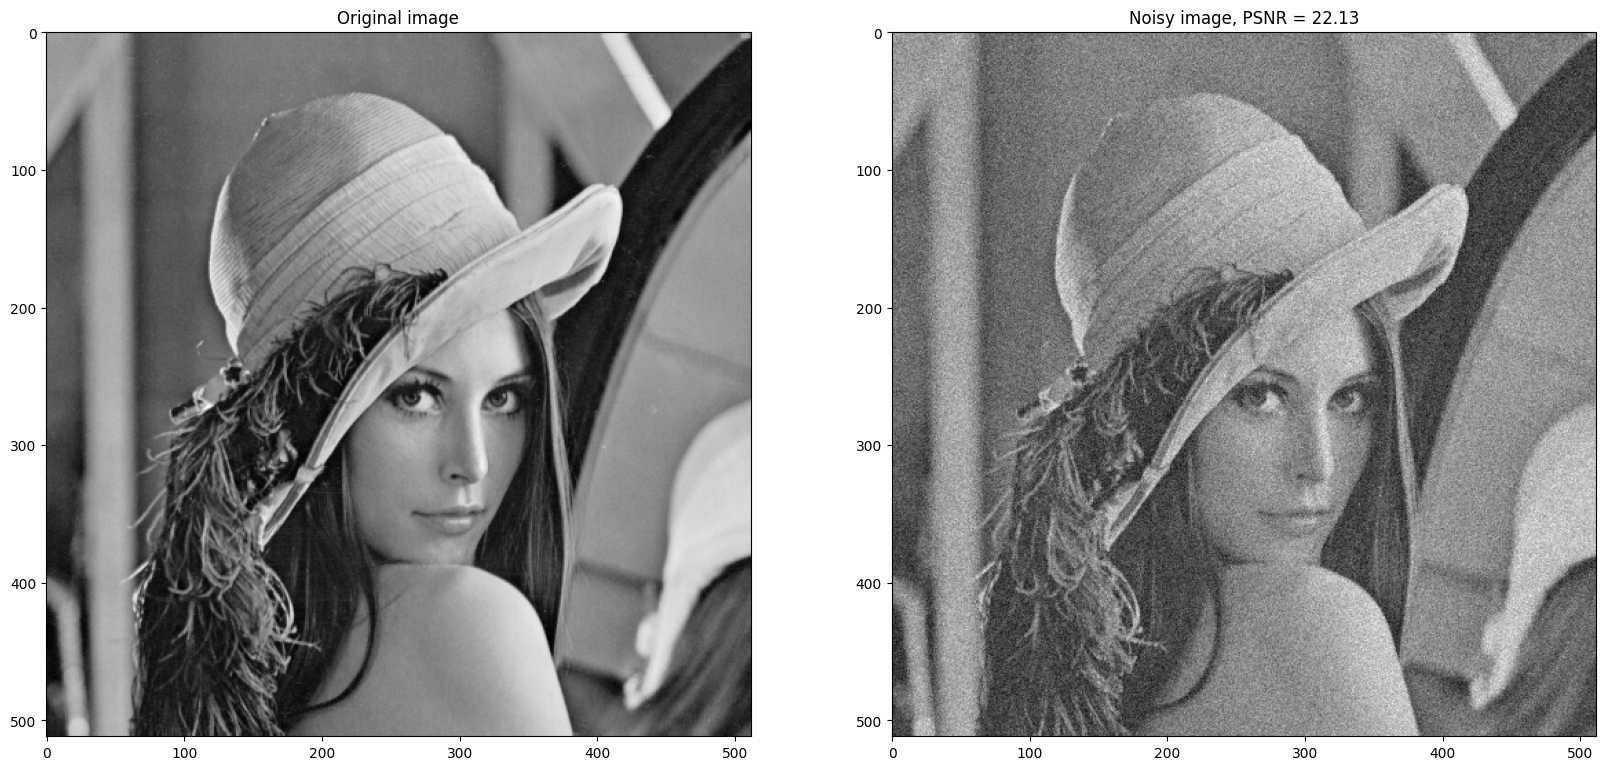

In [186]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Generate the Global PCA basis for this image
--------------------------------------------

Set the parameters for denoising

In [187]:
# set the threshold for the Hard Thresholding
tau = 3 * sigma_noise # Donoho says: sigma * sqrt(2*log(p^2))

Stack all the image patches in a large matrix $S$. Each patch goes in a column of $S$

In [188]:
S = np.zeros((M, (imsz[0] - p + 1) * (imsz[1] - p + 1)))
idx = 0
for i in range(imsz[0] - p + 1):
    for j in range(imsz[1] - p + 1):
        patch = noisy_img[i:i+p, j:j+p]
        S[:, idx] = patch.flatten()
        idx += 1


Compute $\tilde S$ by zero centering $S$


In [189]:
avg_patch = np.mean(S, axis=1, keepdims=True)
Stilde = S - avg_patch

Compute the PCA transformation via SVD


In [190]:
# U, Sigma, V
# U, Sigma, V = np.linalg.svd(Stilde, full_matrices=False)

# not used for my image because it is too heavy

In [191]:
if Myimg == False:
  U, Sigma, V = np.linalg.svd(Stilde, full_matrices=False)
else:
  # covariance matrix and faster svd for my image which is bigger (2560x2560)
  C = Stilde @ Stilde.T

  autovalori, U = np.linalg.eigh(C)

  U = U[:, ::-1]
  autovalori = autovalori[::-1]

  Sigma = np.sqrt(np.maximum(autovalori, 0))

Show the learned PCA basis

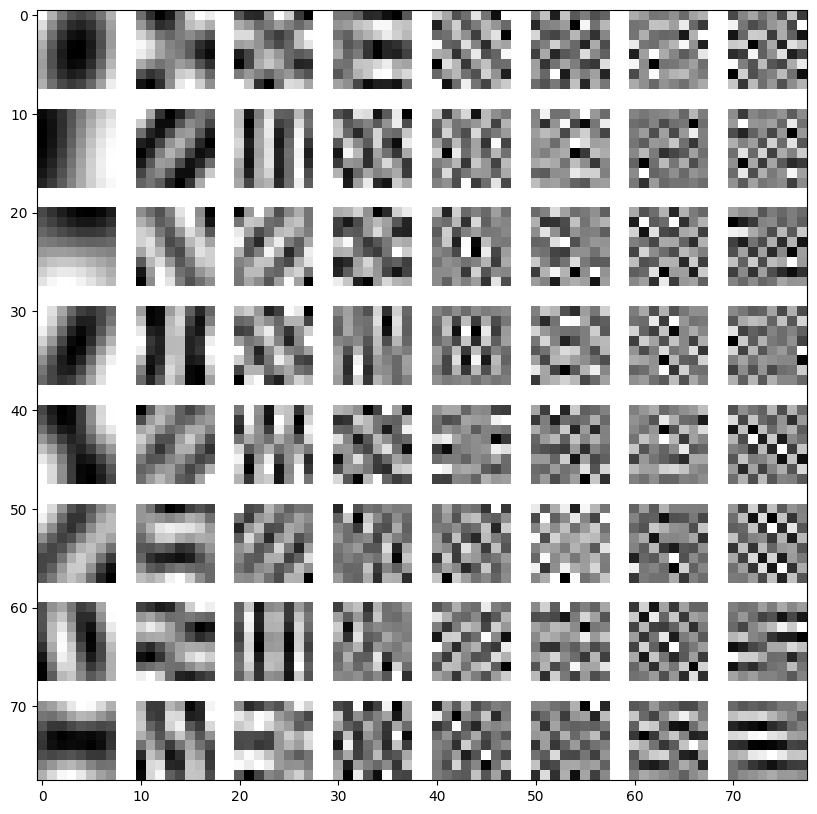

In [192]:
U_img = get_dictionary_img(U)
plt.figure(figsize=(10,10))
plt.imshow(U_img, cmap='gray')


Patch-based denoising
---------------------
Initialize the variables

In [193]:
STEP = 1

# initialize the estimated image
img_hat = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

In [194]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = noisy_img[i:i+p, j:j+p].flatten().reshape(-1,1)

        # Preprocessing: remember to subtract the avg_patch (preprocessing used for PCA)
        s = s - avg_patch

        # compute the representation w.r.t. the PCA basis
        x_hat = U.T @ s
        # perform the hard thresholding
        x_hat[np.abs(x_hat) < tau] = 0
        # synthesis: perform the reconstruction
        y_hat = U @ x_hat

        # add the avg patch back
        y_hat = y_hat + avg_patch
        y_hat_2d = y_hat.reshape((p, p))

        # compute the weight for the reconstructed patch
        w = 1

        # put the denoised patch into the denoised image using the computed weight
        img_hat[i:i+p, j:j+p] = img_hat[i:i+p, j:j+p] + w * (y_hat_2d)

        # store the weight of the current patch in the weight matrix
        weights[i:i+p, j:j+p] += w

# normalize the estimated image with the computed weights
img_hat /= (weights)

Compute the psnr of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 32.12')

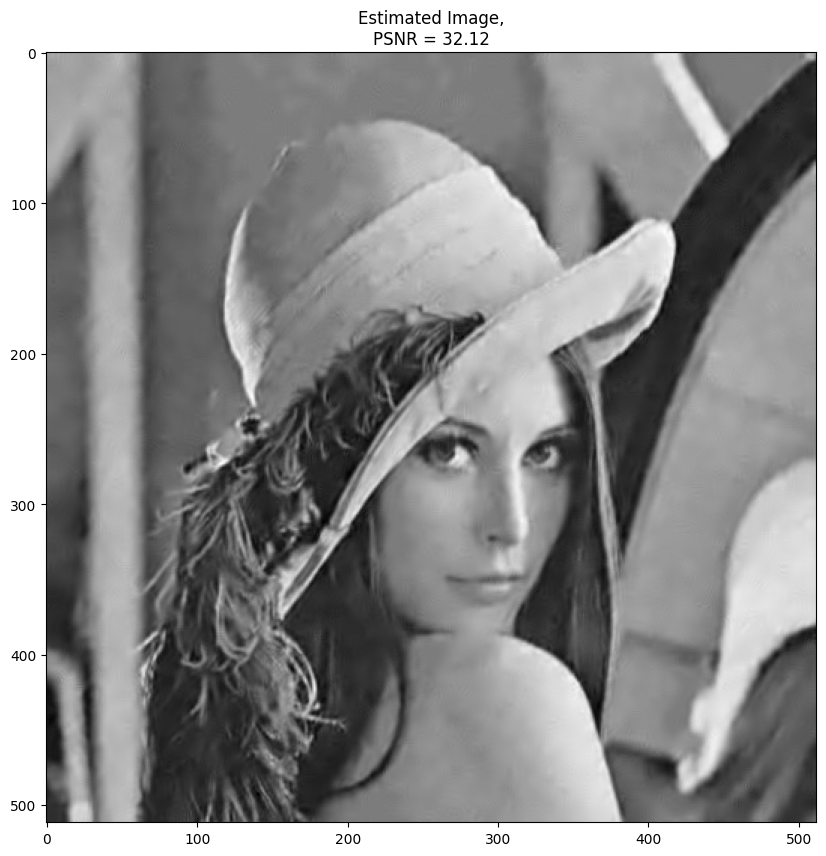

In [195]:
psnr_hat = 10 * np.log10(1 / np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')


Starting PSNR and Time calculation for different STEP values...
Processing with STEP = 1...
-> End STEP = 1 | PSNR: 32.12 | Time: 6.59 sec
Processing with STEP = 2...
-> End STEP = 2 | PSNR: 31.83 | Time: 1.54 sec
Processing with STEP = 3...
-> End STEP = 3 | PSNR: 31.49 | Time: 1.00 sec
Processing with STEP = 4...
-> End STEP = 4 | PSNR: 30.91 | Time: 0.61 sec
Processing with STEP = 5...
-> End STEP = 5 | PSNR: 22.87 | Time: 0.40 sec
Processing with STEP = 6...
-> End STEP = 6 | PSNR: 29.89 | Time: 0.31 sec
Processing with STEP = 7...
-> End STEP = 7 | PSNR: 29.40 | Time: 0.21 sec
Processing with STEP = 8...
-> End STEP = 8 | PSNR: 28.50 | Time: 0.15 sec


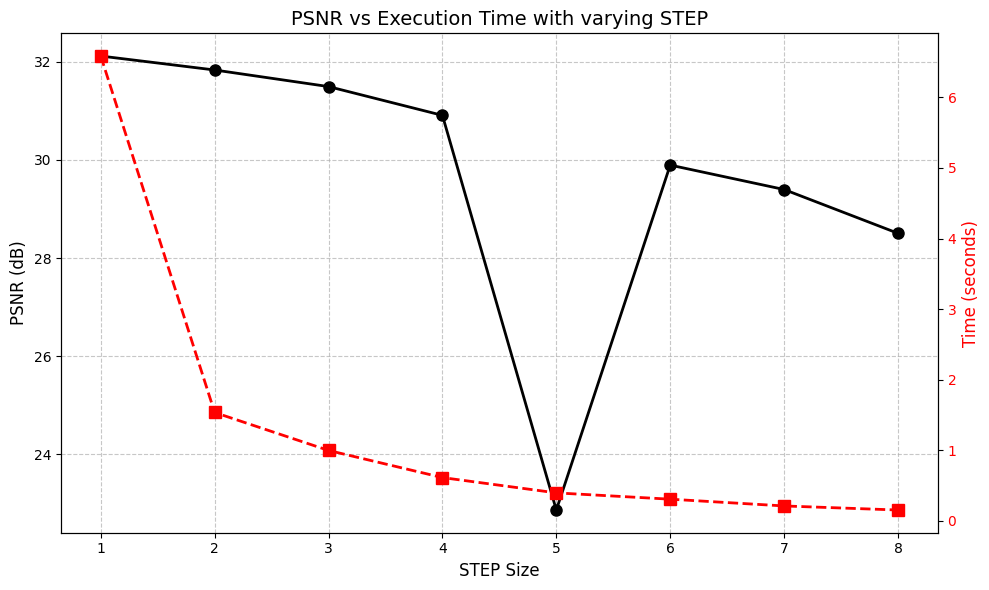

In [196]:
import time
import matplotlib.pyplot as plt
import numpy as np

step_sizes = range(1, 9)  # From 1 to 8 inclusive
psnr_values = []
time_values = []  # Nuova lista per salvare i tempi

print("Starting PSNR and Time calculation for different STEP values...")

for STEP in step_sizes:
    print(f"Processing with STEP = {STEP}...")

    # Registriamo il tempo di inizio per questo STEP
    start_time = time.time()

    # Initialize image and weights to zero for each new loop
    img_hat = np.zeros(noisy_img.shape)
    weights = np.zeros(noisy_img.shape)

    # Reconstruction loop
    for i in range(0, imsz[0] - p + 1, STEP):
        for j in range(0, imsz[1] - p + 1, STEP):
            s = noisy_img[i:i+p, j:j+p].flatten().reshape(-1, 1)
            s = s - avg_patch

            x_hat = U.T @ s
            x_hat[np.abs(x_hat) < tau] = 0
            y_hat = U @ x_hat

            y_hat = y_hat + avg_patch
            y_hat_2d = y_hat.reshape((p, p))

            img_hat[i:i+p, j:j+p] += y_hat_2d
            weights[i:i+p, j:j+p] += 1

    # Normalization
    img_hat_final = img_hat / (weights + 1e-12)

    # PSNR calculation
    mse = np.mean((img - img_hat_final) ** 2)
    if mse == 0:
        psnr = 100  # Avoid division by zero if images are identical
    else:
        psnr = 10 * np.log10(1.0 / mse)

    # Registriamo il tempo di fine e calcoliamo la durata
    end_time = time.time()
    elapsed_time = end_time - start_time

    psnr_values.append(psnr)
    time_values.append(elapsed_time)

    print(f"-> End STEP = {STEP} | PSNR: {psnr:.2f} | Time: {elapsed_time:.2f} sec")

fig, ax1 = plt.subplots(figsize=(10, 6))

# PSNR
color_psnr = 'black'
ax1.set_xlabel('STEP Size', fontsize=12)
ax1.set_ylabel('PSNR (dB)', color=color_psnr, fontsize=12)
ax1.plot(step_sizes, psnr_values, marker='o', linestyle='-', color=color_psnr, linewidth=2, markersize=8, label='PSNR')
ax1.tick_params(axis='y', labelcolor=color_psnr)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(step_sizes)

# Time
ax2 = ax1.twinx()
color_time = 'red'
ax2.set_ylabel('Time (seconds)', color=color_time, fontsize=12)
ax2.plot(step_sizes, time_values, marker='s', linestyle='--', color=color_time, linewidth=2, markersize=8, label='Execution Time')
ax2.tick_params(axis='y', labelcolor=color_time)

plt.title('PSNR vs Execution Time with varying STEP', fontsize=14)
fig.tight_layout()

plt.show()